In [3]:
# Train a Spectrum Quality Filter 
import numpy as np
import pandas as pd
import os
import ms_entropy as me

In [4]:
df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_pre_all.csv')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31949 entries, 0 to 31948
Data columns (total 52 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     31949 non-null  int64  
 1   method                                 31949 non-null  object 
 2   splash                                 31949 non-null  object 
 3   version                                31949 non-null  object 
 4   accurate_mass                          31949 non-null  float64
 5   adduct                                 5084 non-null   object 
 6   branch                                 31949 non-null  object 
 7   commit_id                              31949 non-null  object 
 8   created                                31949 non-null  object 
 9   duplicate_of                           0 non-null      float64
 10  hidden                                 31949 non-null  bool   
 11  in

In [6]:
df.head()

,id,method,splash,version,accurate_mass,adduct,branch,commit_id,created,duplicate_of,...,correction_after_min_error,correction_after_error_range,correction_available_standards,correction_before_max_error,correction_before_error_mean,correction_before_min_error,correction_before_error_range,correction_standards_found_in_percent,used_standards,correction_report
0,34656601,5m hilic premier | orbitrap | beh amide | nega...,splash10-001i-9000000000-b64af919c65b9d5a6fb3,LCB2023,80.916803,NaN,FIEHNLAB-3415,a64e968,2025-03-22 12:50:10.544,NaN,...,-3.357369,5.849980,27.0,3.037992,-0.117701,-5.764356,8.802348,70.370370,{splash10-03di-0090000000-3f95c7479d6ee1ee5400...,"{""valid"": true, ""errors"": [{""name"": ""yy_CUDA* ..."
1,34663201,5m hilic premier | orbitrap | beh amide | nega...,splash10-0bu3-9200000000-2e2f7fb34bde0878d91b,LCB2023,209.066697,NaN,FIEHNLAB-3415,a64e968,2025-03-22 13:51:18.204,NaN,...,-3.278244,5.645295,27.0,3.263152,0.236723,-5.194307,8.457459,70.370370,{splash10-03di-0090000000-3f95c7479d6ee1ee5400...,"{""valid"": true, ""errors"": [{""name"": ""yy_CUDA* ..."
2,26665802,5m hilic premier | orbitrap | beh amide | nega...,splash10-004j-5900000000-0efca6fb90f7c06dd456,LCB2023,179.882892,NaN,master,4806c8a,2024-05-15 02:24:43.384,NaN,...,-2.905018,6.161628,27.0,2.210923,-1.062373,-3.970622,6.181545,88.888889,{splash10-03di-0090000000-3f95c7479d6ee1ee5400...,NaN
3,30694666,5m hilic premier | orbitrap | beh amide | nega...,splash10-004j-5900000000-4246e47f8489f48bdc11,LCB2023,210.910759,NaN,FIEHNLAB-3262,3720d56,2024-11-25 08:46:36.882,NaN,...,-3.148573,5.968462,27.0,1.965823,-1.537740,-6.127345,8.093168,81.481481,{splash10-03di-0090000000-3f95c7479d6ee1ee5400...,"{""valid"": true, ""errors"": [{""name"": ""yy_CUDA* ..."
4,23189718,5m hilic premier | orbitrap | beh amide | nega...,splash10-004j-5900000000-82a52ccfed3c0c6bd7c3,LCB2023,178.844057,NaN,FIEHNLAB-2853,4fdcfcd,2024-04-11 18:41:38.452,NaN,...,-3.945258,6.705301,27.0,3.137139,-0.822146,-5.887518,9.024656,96.296296,{splash10-03di-0090000000-3f95c7479d6ee1ee5400...,NaN


In [7]:
import pandas as pd
import numpy as np

def label_spectrum_quality(df):
    """
    Labels spectrum quality based on the 'name' column:
    - 1: likely real spectrum (TP)
    - 0: not real spectrum (TN)
    - NaN: unknown, not used for training

    Parameters:
        df (pd.DataFrame): Your mass spec DataFrame with a 'name' column.

    Returns:
        pd.DataFrame: A copy of the DataFrame with a new column 'spectrum_quality_label'
    """
    df = df.copy()

    def assign_label(name):
        name = str(name).lower()
        if name.startswith("zz"):
            return 0  # TN: not real spectrum
        elif name.startswith("unknown"):
            return np.nan  # unknown; skip for training
        else:
            return 1  # TP: likely real spectrum

    df['spectrum_quality_label'] = df['name'].apply(assign_label)
    return df


In [8]:
df_labeled = label_spectrum_quality(df)
print(df_labeled['spectrum_quality_label'].value_counts(dropna=False))


spectrum_quality_label
NaN    26814
1.0     5044
0.0       91
Name: count, dtype: int64


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve




Confusion Matrix:
 [[   6   12]
 [   5 1004]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.55      0.33      0.41        18
         1.0       0.99      1.00      0.99      1009

    accuracy                           0.98      1027
   macro avg       0.77      0.66      0.70      1027
weighted avg       0.98      0.98      0.98      1027

ROC AUC Score: 0.9558693976434313


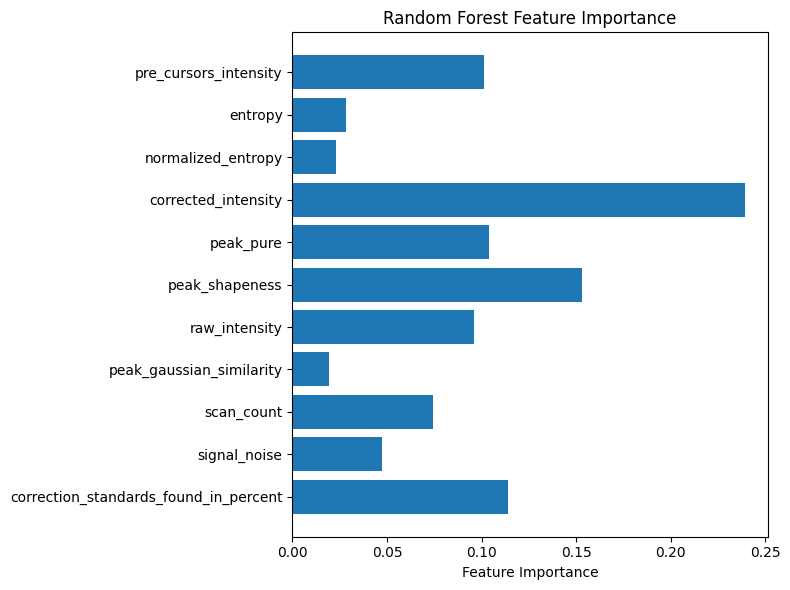

In [13]:

# Step 1: Select your features
quality_features = [
    'pre_cursors_intensity',
    'entropy',
    'normalized_entropy',
    'corrected_intensity',
    'peak_pure',
    'peak_shapeness',
    'raw_intensity',
    'peak_gaussian_similarity',
    'scan_count',
    'signal_noise',
    'correction_standards_found_in_percent'
]

# Step 2: Prepare training data
df_train = df_labeled[df_labeled['spectrum_quality_label'].isin([0, 1])].copy()
X = df_train[quality_features]
y = df_train['spectrum_quality_label']

# Handle missing values (median imputation)
X = X.fillna(X.median())

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Step 4: Train the model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Step 5: Evaluate model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Step 6: Feature importance
importances = model.feature_importances_
plt.figure(figsize=(8, 6))
plt.barh(quality_features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [35]:
print(quality_features)
print(importances)

['pre_cursors_intensity', 'entropy', 'normalized_entropy', 'corrected_intensity', 'peak_pure', 'peak_shapeness', 'raw_intensity', 'peak_gaussian_similarity', 'scan_count', 'signal_noise', 'correction_standards_found_in_percent']
[0.10144863 0.02856768 0.02299051 0.2393352  0.10382587 0.15286921
 0.09574464 0.01937224 0.07433168 0.0475485  0.11396583]


In [23]:

# Step 7: Apply to full dataset
X_full = df_labeled[quality_features].fillna(X.median())
df_labeled['quality_score'] = model.predict_proba(X_full)[:, 1]
# Use a more balanced threshold
df_labeled['pass_quality_filter'] = df_labeled['quality_score'] >= 0.6

# Optionally check how many pass
print(df_labeled['pass_quality_filter'].value_counts())



pass_quality_filter
True     30805
False     1144
Name: count, dtype: int64


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


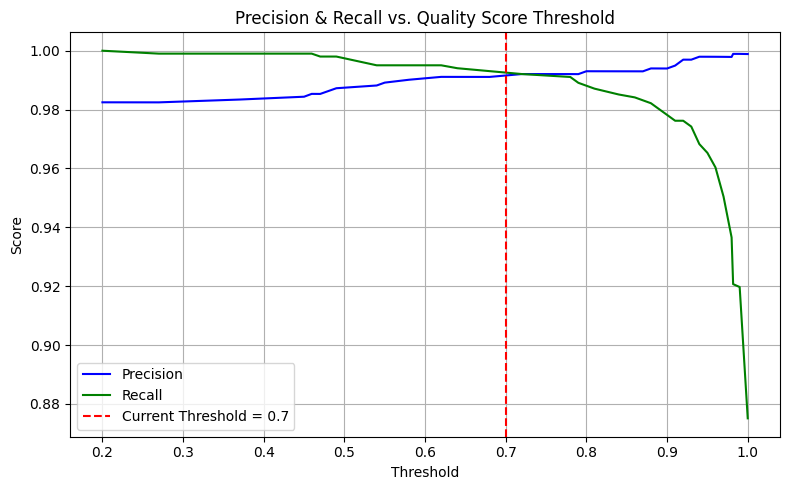

In [22]:

# Generate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot precision and recall as a function of the threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.axvline(x=0.7, color='red', linestyle='--', label='Current Threshold = 0.7')

plt.title('Precision & Recall vs. Quality Score Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


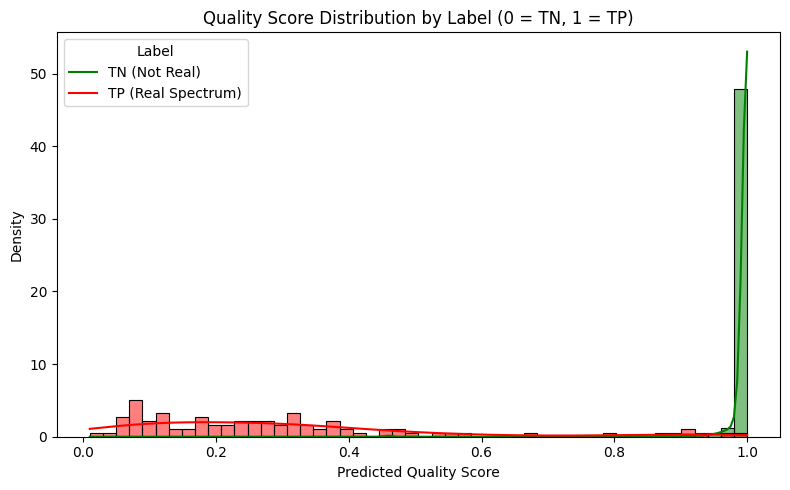

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to labeled spectra only (exclude NaNs)
labeled_scores = df_labeled[df_labeled['spectrum_quality_label'].isin([0, 1])]

# Plot quality score distributions by label
plt.figure(figsize=(8, 5))
sns.histplot(
    data=labeled_scores,
    x='quality_score',
    hue='spectrum_quality_label',
    bins=50,
    kde=True,
    stat='density',
    common_norm=False,
    palette={0: "red", 1: "green"}
)
plt.xlabel("Predicted Quality Score")
plt.ylabel("Density")
plt.title("Quality Score Distribution by Label (0 = TN, 1 = TP)")
plt.legend(title="Label", labels=["TN (Not Real)", "TP (Real Spectrum)"])
plt.tight_layout()
plt.show()


In [31]:
df_labeled['quality_score'].describe()

count    31949.000000
mean         0.954149
std          0.128463
min          0.010000
25%          0.980000
50%          1.000000
75%          1.000000
max          1.000000
Name: quality_score, dtype: float64

In [28]:
df_labeled.describe()

,id,accurate_mass,duplicate_of,inchi_key,pre_cursors_intensity,pre_cursors_mass,retention_index,retention_time,entropy,normalized_entropy,...,correction_after_min_error,correction_after_error_range,correction_available_standards,correction_before_max_error,correction_before_error_mean,correction_before_min_error,correction_before_error_range,correction_standards_found_in_percent,spectrum_quality_label,quality_score
count,3.194900e+04,31949.000000,0.0,0.0,3.194900e+04,31949.000000,31949.000000,31949.000000,3.194900e+04,3.194900e+04,...,31887.000000,31887.000000,31887.000000,31887.000000,31887.000000,31887.000000,31887.000000,31887.000000,5135.000000,31949.000000
mean,2.752128e+07,334.807981,NaN,NaN,1.083052e+07,334.807981,82.706915,81.924574,1.944239e+00,6.701042e-01,...,-2.051460,4.064846,33.544830,4.220913,0.018969,-2.623070,6.843983,91.915315,0.982278,0.954149
std,4.237488e+06,199.582052,NaN,NaN,5.692926e+07,199.582052,46.814247,47.898927,8.105919e-01,2.250433e-01,...,0.833846,1.253106,3.159468,1.902859,1.169534,1.673395,1.443516,9.571057,0.131950,0.128463
min,2.318250e+07,60.055843,NaN,NaN,0.000000e+00,60.055843,1.119488,1.109524,2.389559e-07,9.616294e-08,...,-5.672999,1.039926,27.000000,-1.660913,-3.590518,-12.103864,2.173251,55.555556,0.000000,0.010000
25%,2.377640e+07,177.087019,NaN,NaN,3.929430e+05,177.087019,37.099733,34.251808,1.392125e+00,5.064739e-01,...,-2.445288,3.308344,35.000000,2.752893,-0.815527,-3.339621,5.678042,91.428571,1.000000,0.980000
50%,2.611161e+07,283.111081,NaN,NaN,2.126305e+06,283.111081,88.854227,88.729630,1.898616e+00,6.728850e-01,...,-1.928413,4.100992,35.000000,3.697711,-0.172275,-2.369083,6.644743,97.142857,1.000000,1.000000
75%,3.069483e+07,445.251975,NaN,NaN,8.417647e+06,445.251975,117.272588,118.442154,2.407225e+00,8.514448e-01,...,-1.413335,4.692734,35.000000,5.604152,1.072498,-1.457965,7.913924,97.142857,1.000000,1.000000
max,3.466900e+07,1194.819336,NaN,NaN,2.147484e+09,1194.819336,228.680311,227.612350,5.115073e+00,9.999928e-01,...,-0.354151,8.988219,36.000000,9.780656,2.603010,0.792299,16.398096,100.000000,1.000000,1.000000


In [33]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=50, scoring='roc_auc')
print("Cross-validated AUC:", scores.mean())


Cross-validated AUC: 0.9556628712871289


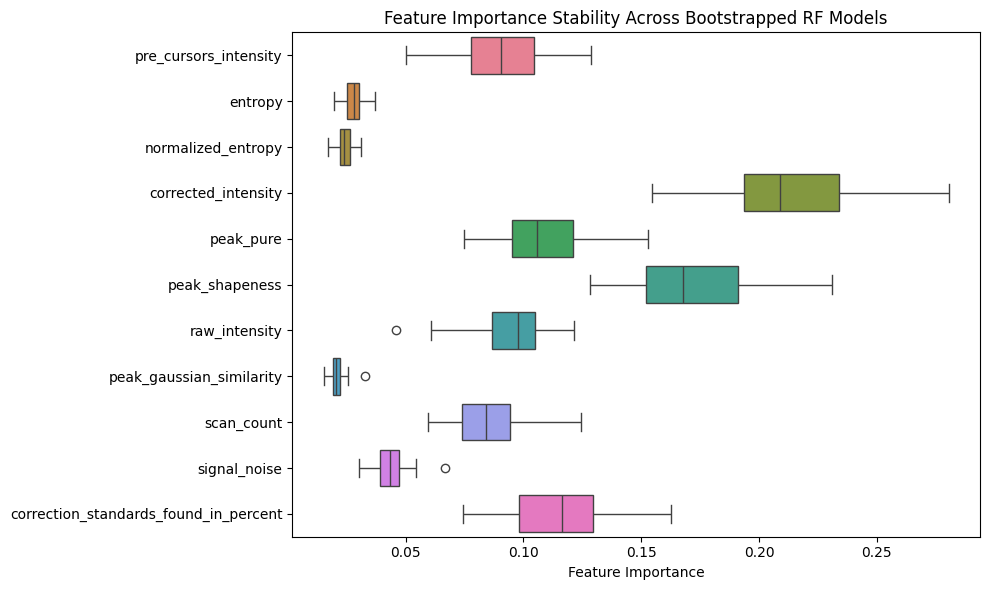

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Step 1: Define features
quality_features = [
    'pre_cursors_intensity', 'entropy', 'normalized_entropy',
    'corrected_intensity', 'peak_pure', 'peak_shapeness',
    'raw_intensity', 'peak_gaussian_similarity', 'scan_count',
    'signal_noise', 'correction_standards_found_in_percent'
]

# Step 2: Prepare labeled data
df_train = df_labeled[df_labeled['spectrum_quality_label'].isin([0, 1])].copy()
X_full = df_train[quality_features].fillna(df_train[quality_features].median())
y_full = df_train['spectrum_quality_label']

# Step 3: Bootstrap feature importances
n_bootstraps = 50
importances = []

for seed in range(n_bootstraps):
    tn = df_train[df_train['spectrum_quality_label'] == 0]
    tp = df_train[df_train['spectrum_quality_label'] == 1].sample(n=500, random_state=seed)
    df_boot = pd.concat([tp, tn])
    X_boot = df_boot[quality_features].fillna(X_full.median())
    y_boot = df_boot['spectrum_quality_label']

    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=seed)
    model.fit(X_boot, y_boot)
    importances.append(model.feature_importances_)

# Step 4: Convert to DataFrame
importance_df = pd.DataFrame(importances, columns=quality_features)

# Step 5: Plot feature importance stability
plt.figure(figsize=(10, 6))
sns.boxplot(data=importance_df, orient='h')
plt.xlabel("Feature Importance")
plt.title("Feature Importance Stability Across Bootstrapped RF Models")
plt.tight_layout()
plt.show()


In [39]:
summary_stats = importance_df.aggregate(['mean', 'std']).T
summary_stats = summary_stats.rename(columns={'mean': 'Mean Importance', 'std': 'Std Dev'})
summary_stats = summary_stats.sort_values('Mean Importance', ascending=False)
print(summary_stats)

                                       Mean Importance   Std Dev
corrected_intensity                           0.214475  0.027897
peak_shapeness                                0.173913  0.027876
correction_standards_found_in_percent         0.115404  0.021264
peak_pure                                     0.107861  0.019648
raw_intensity                                 0.095612  0.015979
pre_cursors_intensity                         0.090997  0.017042
scan_count                                    0.085133  0.014435
signal_noise                                  0.043603  0.006569
entropy                                       0.027898  0.003992
normalized_entropy                            0.024328  0.003026
peak_gaussian_similarity                      0.020775  0.002888


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Updated feature list: drop low-importance features
selected_features = [
    'corrected_intensity',
    'peak_shapeness',
    'correction_standards_found_in_percent',
    'peak_pure',
    'raw_intensity',
    'pre_cursors_intensity',
    'scan_count'
]

# Prepare data
df_train = df_labeled[df_labeled['spectrum_quality_label'].isin([0, 1])].copy()
X = df_train[selected_features].fillna(df_train[selected_features].median())
y = df_train['spectrum_quality_label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

results = {
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

results


{'confusion_matrix': array([[   8,   10],
        [   5, 1004]]),
 'classification_report': {'0.0': {'precision': 0.6153846153846154,
   'recall': 0.4444444444444444,
   'f1-score': 0.5161290322580646,
   'support': 18.0},
  '1.0': {'precision': 0.9901380670611439,
   'recall': 0.9950445986124876,
   'f1-score': 0.9925852694018784,
   'support': 1009.0},
  'accuracy': 0.98539435248296,
  'macro avg': {'precision': 0.8027613412228797,
   'recall': 0.719744521528466,
   'f1-score': 0.7543571508299716,
   'support': 1027.0},
  'weighted avg': {'precision': 0.9835698468759662,
   'recall': 0.98539435248296,
   'f1-score': 0.984234527173457,
   'support': 1027.0}},
 'roc_auc': 0.9526483867415483}

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Redefine data with reduced features
df_train = df_labeled[df_labeled['spectrum_quality_label'].isin([0, 1])].copy()
X = df_train[selected_features].fillna(df_train[selected_features].median())
y = df_train['spectrum_quality_label']

# Set up stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Get CV predictions
y_pred_cv = cross_val_predict(model, X, y, cv=skf)
y_proba_cv = cross_val_predict(model, X, y, cv=skf, method='predict_proba')[:, 1]

# Evaluate
cv_results = {
    "confusion_matrix": confusion_matrix(y, y_pred_cv),
    "classification_report": classification_report(y, y_pred_cv, output_dict=True),
    "roc_auc": roc_auc_score(y, y_proba_cv)
}

cv_results


{'confusion_matrix': array([[  42,   49],
        [  14, 5030]]),
 'classification_report': {'0.0': {'precision': 0.75,
   'recall': 0.46153846153846156,
   'f1-score': 0.5714285714285714,
   'support': 91.0},
  '1.0': {'precision': 0.9903524315810199,
   'recall': 0.9972244250594766,
   'f1-score': 0.9937765484540156,
   'support': 5044.0},
  'accuracy': 0.9877312560856865,
  'macro avg': {'precision': 0.87017621579051,
   'recall': 0.7293814432989691,
   'f1-score': 0.7826025599412936,
   'support': 5135.0},
  'weighted avg': {'precision': 0.986093021401103,
   'recall': 0.9877312560856865,
   'f1-score': 0.9862919007598938,
   'support': 5135.0}},
 'roc_auc': 0.952658364632988}

In [45]:
# final code:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define features to keep
selected_features = [
    'corrected_intensity',
    'peak_shapeness',
    'correction_standards_found_in_percent',
    'peak_pure',
    'raw_intensity',
    'pre_cursors_intensity',
    'scan_count'
]

# Prepare data
df = df_labeled[df_labeled['spectrum_quality_label'].isin([0, 1])].copy()
X = df[selected_features].fillna(df[selected_features].median())
y = df['spectrum_quality_label']

# Train model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X, y)

# Predict probabilities and labels
y_pred = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))
print("ROC AUC Score:", roc_auc_score(y, y_proba))

# Attach scores to original data
df['predicted_proba'] = y_proba


Confusion Matrix:
 [[  90    1]
 [   0 5044]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99        91
         1.0       1.00      1.00      1.00      5044

    accuracy                           1.00      5135
   macro avg       1.00      0.99      1.00      5135
weighted avg       1.00      1.00      1.00      5135

ROC AUC Score: 0.9999324624622008


In [46]:
df_new = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_all.csv')


/var/folders/xd/3y34jslx1fsf1k1pd0bz8w3r0000gn/T/ipykernel_52798/3604314487.py:1: DtypeWarning: Columns (11,28,50,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_all.csv')


In [47]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49268 entries, 0 to 49267
Data columns (total 52 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     49268 non-null  int64  
 1   method                                 49268 non-null  object 
 2   splash                                 49268 non-null  object 
 3   version                                49268 non-null  object 
 4   accurate_mass                          49268 non-null  float64
 5   adduct                                 2321 non-null   object 
 6   branch                                 41208 non-null  object 
 7   commit_id                              41208 non-null  object 
 8   created                                49268 non-null  object 
 9   duplicate_of                           0 non-null      float64
 10  hidden                                 49268 non-null  bool   
 11  in

In [1]:
df_new.head()

NameError: name 'df_new' is not defined

In [52]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Step 1: Label the new dataset (reuse your function)
def label_spectrum_quality(df):
    df = df.copy()
    def assign_label(name):
        name = str(name).lower()
        if name.startswith("zz"):
            return 0  # TN
        elif name.startswith("unknown"):
            return np.nan  # Unknown
        else:
            return 1  # TP
    df['spectrum_quality_label'] = df['name'].apply(assign_label)
    return df

new_df = label_spectrum_quality(df_new)

# Step 2: Prepare features for prediction
selected_features = [
    'corrected_intensity',
    'peak_shapeness',
    'correction_standards_found_in_percent',
    'peak_pure',
    'raw_intensity',
    'pre_cursors_intensity',
    'scan_count'
]

X_new = new_df[selected_features].copy()
X_new = X_new.fillna(X_new.median())

# Step 3: Predict quality scores using the trained model
new_df['predicted_score'] = model.predict_proba(X_new)[:, 1]
new_df['predicted_label'] = (new_df['predicted_score'] >= 0.8).astype(int)

# Step 4: Evaluate performance only on labeled examples
eval_df = new_df.dropna(subset=['spectrum_quality_label'])
y_true = eval_df['spectrum_quality_label'].astype(int)
y_pred = eval_df['predicted_label']
y_proba = eval_df['predicted_score']

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("ROC AUC Score:", roc_auc_score(y_true, y_proba))


Confusion Matrix:
 [[  76   31]
 [ 270 2492]]

Classification Report:
               precision    recall  f1-score   support

           0       0.22      0.71      0.34       107
           1       0.99      0.90      0.94      2762

    accuracy                           0.90      2869
   macro avg       0.60      0.81      0.64      2869
weighted avg       0.96      0.90      0.92      2869

ROC AUC Score: 0.8917298855630824


In [53]:
reverse_df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/15m_orbi_c18_all.csv')

In [56]:
reverse_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34337 entries, 0 to 34336
Data columns (total 52 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     34337 non-null  int64  
 1   method                                 34337 non-null  object 
 2   splash                                 34337 non-null  object 
 3   version                                34337 non-null  object 
 4   accurate_mass                          34337 non-null  float64
 5   adduct                                 831 non-null    object 
 6   branch                                 34337 non-null  object 
 7   commit_id                              34337 non-null  object 
 8   created                                34337 non-null  object 
 9   duplicate_of                           0 non-null      float64
 10  hidden                                 34337 non-null  bool   
 11  in

In [57]:
ttof_df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_ttof_all.csv')

/var/folders/xd/3y34jslx1fsf1k1pd0bz8w3r0000gn/T/ipykernel_52798/538617005.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  ttof_df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_ttof_all.csv')


In [58]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Step 1: Label the new dataset (reuse your function)
def label_spectrum_quality(df):
    df = df.copy()
    def assign_label(name):
        name = str(name).lower()
        if name.startswith("zz"):
            return 0  # TN
        elif name.startswith("unknown"):
            return np.nan  # Unknown
        else:
            return 1  # TP
    df['spectrum_quality_label'] = df['name'].apply(assign_label)
    return df

new_df = label_spectrum_quality(ttof_df)

# Step 2: Prepare features for prediction
selected_features = [
    'corrected_intensity',
    'peak_shapeness',
    'correction_standards_found_in_percent',
    'peak_pure',
    'raw_intensity',
    'pre_cursors_intensity',
    'scan_count'
]

X_new = new_df[selected_features].copy()
X_new = X_new.fillna(X_new.median())

# Step 3: Predict quality scores using the trained model
new_df['predicted_score'] = model.predict_proba(X_new)[:, 1]
new_df['predicted_label'] = (new_df['predicted_score'] >= 0.8).astype(int)

# Step 4: Evaluate performance only on labeled examples
eval_df = new_df.dropna(subset=['spectrum_quality_label'])
y_true = eval_df['spectrum_quality_label'].astype(int)
y_pred = eval_df['predicted_label']
y_proba = eval_df['predicted_score']

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("ROC AUC Score:", roc_auc_score(y_true, y_proba))


Confusion Matrix:
 [[   0    3]
 [  87 3986]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       1.00      0.98      0.99      4073

    accuracy                           0.98      4076
   macro avg       0.50      0.49      0.49      4076
weighted avg       1.00      0.98      0.99      4076

ROC AUC Score: 0.4580980440297897
